##  House Prices Regression

In [1]:
# Loading the data 
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("house_price_prediction_dataset.csv")

# Basic info
df.shape
df.head()
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Initial feature classification based on data types showed 43 categorical and 38 numerical variables. However, certain features like MSSubClass, although stored as integers, represent categorical information and were converted accordingly. Additionally, identifier columns such as Id were removed as they do not contribute to prediction.

In [2]:
#remove id
df.drop('Id', axis=1, inplace=True)

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop("SalePrice", axis=1)
y = np.log1p(df["SalePrice"])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:

#fix hte colum nature
X_train['MSSubClass'] = X_train['MSSubClass'].astype(str)
X_test['MSSubClass'] = X_test['MSSubClass'].astype(str)

cat_cols_train = X_train.select_dtypes(include=['object']).columns
num_cols_train = X_train.select_dtypes(exclude=['object']).columns

cat_cols_test = X_test.select_dtypes(include=['object']).columns
num_cols_test = X_test.select_dtypes(exclude=['object']).columns

print("Categorical:", len(cat_cols_train))
print("Numerical:", len(num_cols_test))

Categorical: 44
Numerical: 35


Some numeric-looking columns are actually categorical:

Example:

MSSubClass → should be categorical

Features were divided into categorical and numerical types based on data types. Some numerical-looking variables like MSSubClass were converted to categorical as they represent classes rather than continuous values.

In [5]:
# Target variable
y_train.describe()

count    1168.000000
mean       12.030658
std         0.390606
min        10.460271
25%        11.775297
50%        12.013707
75%        12.278049
max        13.521141
Name: SalePrice, dtype: float64

In [6]:
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

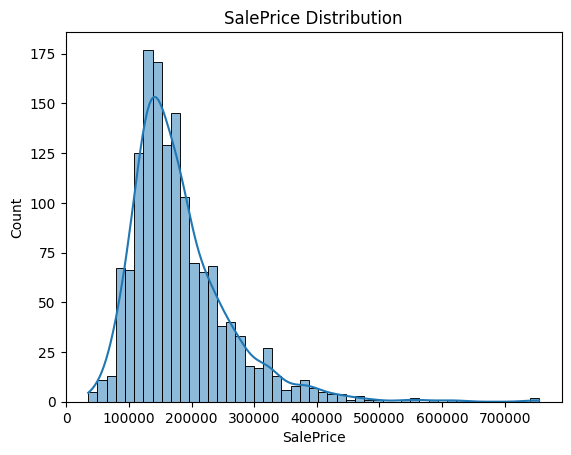

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

SalePrice is right-skewed
Few houses have very high prices (outliers)
Models like Linear Regression work better with normal distribution

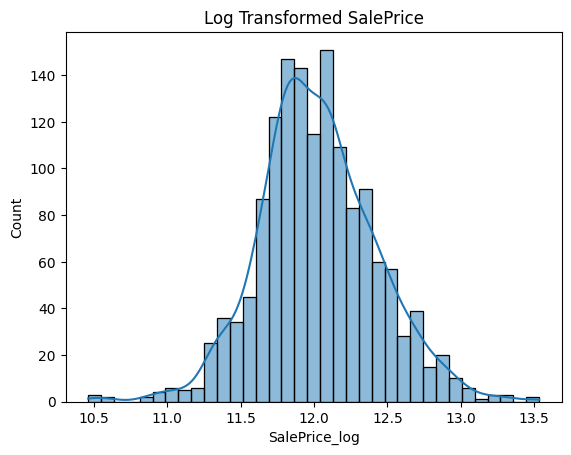

In [8]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

sns.histplot(df['SalePrice_log'], kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

Mising Value Analysis

In [9]:
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_percent = (missing / len(X_train)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df.head(20)

,Missing Count,Missing %
PoolQC,1162,99.486301
MiscFeature,1122,96.061644
Alley,1094,93.664384
Fence,935,80.051370
MasVnrType,683,58.476027
FireplaceQu,547,46.832192
LotFrontage,217,18.578767
GarageType,64,5.479452
GarageYrBlt,64,5.479452
GarageFinish,64,5.479452


In [10]:
missing = X_test.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_percent = (missing / len(X_test)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df.head(20)

,Missing Count,Missing %
PoolQC,291,99.657534
MiscFeature,284,97.260274
Alley,275,94.178082
Fence,244,83.561644
MasVnrType,189,64.726027
FireplaceQu,143,48.972603
LotFrontage,42,14.383562
GarageType,17,5.821918
GarageYrBlt,17,5.821918
GarageFinish,17,5.821918


In [11]:
#column were none is as value
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
for col in none_cols:
    X_train[col] = X_train[col].fillna('None')
    X_test[col] = X_test[col].fillna('None')

# imputing numerical colum with median
lotfrontage_median = X_train["LotFrontage"].median()
X_train["LotFrontage"] = X_train["LotFrontage"].fillna(lotfrontage_median)
X_test["LotFrontage"] = X_test["LotFrontage"].fillna(lotfrontage_median)

garage_num_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars']

#Garage column
for col in garage_num_cols:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)


bsmt_num_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']

for col in bsmt_num_cols:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']

for col in mode_cols:
    train_mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(train_mode)
    X_test[col] = X_test[col].fillna(train_mode)

The dataset contains several missing values across both categorical and numerical features. Based on dataset description, missing values in features such as PoolQC, Alley, Fence, and basement/garage-related categorical columns were interpreted as absence of the feature and were filled with "None".

Numerical features related to garage and basement were filled with 0, indicating the non-existence of these facilities.

Features with genuine missing values such as LotFrontage were imputed using the median to avoid the influence of outliers.

Remaining categorical features were imputed using the mode (most frequent value).

After imputation, no missing values remained in the dataset.

In [12]:
#check if  all missing values handelled
X_train.isnull().sum().sum() 
X_test.isnull().sum().sum() 

np.int64(191)

In [13]:
# check waht is remaining in missing data analysis
missing_train = X_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(missing_train)

MasVnrType    683
MasVnrArea      6
dtype: int64


In [14]:
missing_test = X_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(missing_test)

MasVnrType    189
MasVnrArea      2
dtype: int64


The MasVnrType feature represents the type of masonry veneer used in the house. Missing values in this column were interpreted as the absence of veneer and were imputed with "None". The corresponding numerical feature MasVnrArea was filled with 0 to maintain consistency, indicating no veneer area.

In [15]:
# Masonry veneer columns
X_train["MasVnrType"] = X_train["MasVnrType"].fillna("None")
X_test["MasVnrType"] = X_test["MasVnrType"].fillna("None")

X_train["MasVnrArea"] = X_train["MasVnrArea"].fillna(0)
X_test["MasVnrArea"] = X_test["MasVnrArea"].fillna(0)

# Validate everything fixed
print("Train missing:", X_train.isnull().sum().sum())
print("Test missing:", X_test.isnull().sum().sum())

Train missing: 0
Test missing: 0


After initial imputation, some missing values remained in basement, garage, and masonry veneer-related features. These were subsequently handled by imputing categorical features with "None" and numerical features with 0, ensuring complete removal of missing values.

In [16]:
#identify column types after cleaning
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

Categorical: 44
Numerical: 35


Encoding Based on Data Dictionary:

In [17]:
# Quality-based features
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

qual_cols = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
    "HeatingQC", "KitchenQual", "FireplaceQu",
    "GarageQual", "GarageCond", "PoolQC"
]

for col in qual_cols:
    X_train[col] = X_train[col].map(quality_map)
    X_test[col] = X_test[col].map(quality_map)


bsmt_exposure_map = {
    "None": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

X_train["BsmtExposure"] = X_train["BsmtExposure"].map(bsmt_exposure_map)
X_test["BsmtExposure"] = X_test["BsmtExposure"].map(bsmt_exposure_map)

bsmt_fin_map = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

X_train["BsmtFinType1"] = X_train["BsmtFinType1"].map(bsmt_fin_map)
X_test["BsmtFinType1"] = X_test["BsmtFinType1"].map(bsmt_fin_map)

X_train["BsmtFinType2"] = X_train["BsmtFinType2"].map(bsmt_fin_map)
X_test["BsmtFinType2"] = X_test["BsmtFinType2"].map(bsmt_fin_map)

garage_finish_map = {
    "None": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

X_train["GarageFinish"] = X_train["GarageFinish"].map(garage_finish_map)
X_test["GarageFinish"] = X_test["GarageFinish"].map(garage_finish_map)

functional_map = {
    "Sal": 1,
    "Sev": 2,
    "Maj2": 3,
    "Maj1": 4,
    "Mod": 5,
    "Min2": 6,
    "Min1": 7,
    "Typ": 8
}

X_train["Functional"] = X_train["Functional"].map(functional_map)
X_test["Functional"] = X_test["Functional"].map(functional_map)

NOMINAL FEATURES --> one hot encoded

In [18]:
cat_cols = X_train.select_dtypes(include=["object"]).columns

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align train and test columns
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [19]:
# 1. Check bool columns
print("Train bool columns:", X_train.select_dtypes(include="bool").columns.tolist())
print("Test bool columns:", X_test.select_dtypes(include="bool").columns.tolist())

# 2. Check total missing values
print("Train total missing:", X_train.isnull().sum().sum())
print("Test total missing:", X_test.isnull().sum().sum())

# 3. Check columns with remaining missing values
print("\nTrain columns with missing:")
for col in X_train.columns:
    if X_train[col].isnull().sum() > 0:
        print(col)

print("\nTest columns with missing:")
for col in X_test.columns:
    if X_test[col].isnull().sum() > 0:
        print(col)

Train bool columns: ['MSSubClass_160', 'MSSubClass_180', 'MSSubClass_190', 'MSSubClass_20', 'MSSubClass_30', 'MSSubClass_40', 'MSSubClass_45', 'MSSubClass_50', 'MSSubClass_60', 'MSSubClass_70', 'MSSubClass_75', 'MSSubClass_80', 'MSSubClass_85', 'MSSubClass_90', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Pave', 'Alley_None', 'Alley_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown'

After one-hot encoding, some features were represented as boolean values (True/False). These were converted to binary (0/1) format to ensure compatibility with machine learning algorithms. SO now we have 172 features

In [20]:
X_train

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,70.0,8400,5,6,1957,1957,0.0,3,4,3,...,False,False,False,False,True,False,False,False,True,False
1066,59.0,7837,6,7,1993,1994,0.0,4,3,4,...,False,False,False,False,True,False,False,False,True,False
638,67.0,8777,5,7,1910,1950,0.0,3,3,2,...,False,False,False,False,True,False,False,False,True,False
799,60.0,7200,5,7,1937,1950,252.0,3,3,4,...,False,False,False,False,True,False,False,False,True,False
380,50.0,5000,5,6,1924,1950,0.0,3,3,3,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,78.0,9317,6,5,2006,2006,0.0,4,3,4,...,False,False,False,False,True,False,False,False,True,False
1130,65.0,7804,4,3,1928,1950,0.0,3,3,3,...,False,False,False,False,True,False,False,False,True,False
1294,60.0,8172,5,7,1955,1990,0.0,3,3,3,...,False,False,False,False,True,False,False,False,True,False
860,55.0,7642,7,8,1918,1998,0.0,4,3,3,...,False,False,False,False,True,False,False,False,True,False


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Step 1: Select numeric columns from TRAIN only
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Step 2: Separate binary and continuous columns
binary_cols = [col for col in num_cols if X_train[col].nunique() == 2]
cont_cols = [col for col in num_cols if col not in binary_cols]

# Step 3: Scale ONLY continuous columns
X_train[cont_cols] = scaler.fit_transform(X_train[cont_cols])
X_test[cont_cols] = scaler.transform(X_test[cont_cols])

# Step 4: Check result
X_train.head(10)

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,-0.012468,-0.212896,-0.820445,0.372217,-0.455469,-1.346063,-0.597889,-0.687421,2.520919,-0.566201,...,False,False,False,False,True,False,False,False,True,False
1066,-0.502357,-0.265245,-0.088934,1.268609,0.718609,0.439214,-0.597889,1.054244,-0.241214,0.585929,...,False,False,False,False,True,False,False,False,True,False
638,-0.146074,-0.177841,-0.820445,1.268609,-1.988293,-1.683818,-0.597889,-0.687421,-0.241214,-1.718330,...,False,False,False,False,True,False,False,False,True,False
799,-0.457822,-0.324474,-0.820445,1.268609,-1.107734,-1.683818,0.861522,-0.687421,-0.241214,0.585929,...,False,False,False,False,True,False,False,False,True,False
380,-0.903175,-0.529035,-0.820445,0.372217,-1.531707,-1.683818,-0.597889,-0.687421,-0.241214,-0.566201,...,False,False,False,False,True,False,False,False,True,False
303,-0.012468,-0.082721,-0.820445,1.268609,0.033730,-0.622302,-0.597889,-0.687421,-0.241214,-0.566201,...,False,False,False,False,True,False,False,False,False,False
86,2.303368,0.113564,-0.088934,-0.524174,1.109968,0.969972,-0.597889,1.054244,-0.241214,0.585929,...,False,False,False,False,True,False,False,False,True,False
1385,-1.348528,-0.488495,-1.551955,2.165000,-1.596934,1.066473,-0.597889,-0.687421,2.520919,-0.566201,...,False,False,False,False,True,False,False,False,True,False
265,0.343814,0.130208,-0.088934,0.372217,0.327250,-0.188046,0.618287,-0.687421,2.520919,0.585929,...,False,False,False,False,True,False,False,False,True,False
793,0.254744,-0.142415,1.374088,-0.524174,1.175195,1.066473,0.212895,1.054244,-0.241214,0.585929,...,False,False,True,False,False,False,False,False,False,True


In [22]:
print("Scaled cols:", len(cont_cols))
print("Binary cols:", len(binary_cols))

Scaled cols: 50
Binary cols: 0


Based on the dataset description, categorical variables were divided into ordinal and nominal categories. Ordinal features such as quality-related variables (ExterQual, KitchenQual, etc.) were encoded using ordinal mapping to preserve their ranking.

Nominal variables such as Neighborhood, MSZoning, and Exterior features were transformed using one-hot encoding to avoid introducing artificial ordering.

The feature MSSubClass, although numeric, represents categorical information and was converted to string before encoding.

Finally, numerical features were standardized using StandardScaler to bring all variables onto a comparable scale, improving model performance.

In [23]:
#convert everythong to float - booblean causing issue in LR
X_train = X_train.astype(float)
X_test = X_test.astype(float)

## Baseline models

In [24]:
print("Final train shape:", X_train.shape)
print("Final test shape:", X_test.shape)
print("Train missing:", X_train.isnull().sum().sum())
print("Test missing:", X_test.isnull().sum().sum())

Final train shape: (1168, 220)
Final test shape: (292, 220)
Train missing: 0
Test missing: 0


In [25]:
print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())

10.460270761075149 13.521140839642674
10.471978128496518 13.534474352733596


In [26]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    #rmse_percent = (rmse / y_test.mean()) * 100
    return rmse

In [27]:
lr = LinearRegression()

lr_rmse= evaluate_model(lr, X_train, X_test, y_train, y_test)

print("Linear Regression RMSE:", lr_rmse)

Linear Regression RMSE: 2.6868367772955084


In [28]:
ridge = Ridge(alpha=1.0)

ridge_rmse = evaluate_model(ridge, X_train, X_test, y_train, y_test)

print("Ridge RMSE:", ridge_rmse)

Ridge RMSE: 0.36975192847981353


In [29]:
lasso = Lasso(alpha=0.1, max_iter=10000)

lasso_rmse= evaluate_model(lasso, X_train, X_test, y_train, y_test)

print("Lasso RMSE:", lasso_rmse)

Lasso RMSE: 0.2393790437770913


In [30]:
dt = DecisionTreeRegressor(random_state=42)

dt_rmse= evaluate_model(dt, X_train, X_test, y_train, y_test)

print("Decision Tree RMSE:", dt_rmse)

Decision Tree RMSE: 0.2065795614788633


In [31]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, dt_rmse],

})

results.sort_values(by='RMSE')

,Model,RMSE
3,Decision Tree,0.206580
2,Lasso,0.239379
1,Ridge,0.369752
0,Linear Regression,2.686837


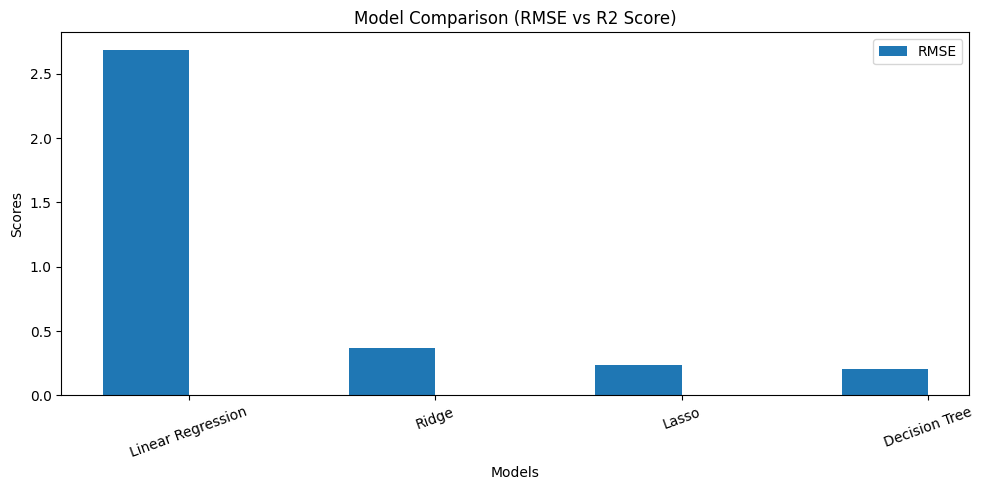

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = results['Model']
rmse = results['RMSE']

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,5))

# Bars
plt.bar(x - width/2, rmse, width, label='RMSE')

# Labels & Title
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Model Comparison (RMSE vs R2 Score)")
plt.xticks(x, models, rotation=20)
plt.legend()

plt.tight_layout()
plt.show()

## Advanced Models & Feature Engineering

In [33]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(random_state=42)
gbr = GradientBoostingRegressor(random_state=42)

1) Log Transform Target

In [34]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_rmse = evaluate_model(rf, X_train, X_test, y_train, y_test)
print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 0.14897056432284173


In [35]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_rmse = evaluate_model(gbr, X_train, X_test, y_train, y_test)
print("Gradient Boosting RMSE:", gbr_rmse)

Gradient Boosting RMSE: 0.13700002799907635


Adding Interactions

In [36]:
# House Age
X_train["HouseAge"] = X_train["YrSold"] - X_train["YearBuilt"]
X_test["HouseAge"]  = X_test["YrSold"] - X_test["YearBuilt"]

# Total Square Footage
X_train["TotalSF"] = (
    X_train["TotalBsmtSF"] +
    X_train["1stFlrSF"] +
    X_train["2ndFlrSF"]
)

X_test["TotalSF"] = (
    X_test["TotalBsmtSF"] +
    X_test["1stFlrSF"] +
    X_test["2ndFlrSF"]
)

# Quality × Area interaction
X_train["Qual_Area"] = X_train["OverallQual"] * X_train["GrLivArea"]
X_test["Qual_Area"]  = X_test["OverallQual"] * X_test["GrLivArea"]

In [37]:
X = df.drop("SalePrice", axis=1)
y = np.log1p(df["SalePrice"])

In [38]:
from sklearn.preprocessing import PolynomialFeatures

base_features = [
    "OverallQual",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "TotalSF",
    "HouseAge"
]
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

X_train_poly = poly.fit_transform(X_train[base_features])
X_test_poly = poly.transform(X_test[base_features])

In [39]:
print("Train shape:", X_train.shape)
print("Rows:", X_train.shape[0])
print("Columns:", X_train.shape[1])

Train shape: (1168, 223)
Rows: 1168
Columns: 223


In [40]:
bool_cols = X_train.select_dtypes(include="bool").columns
print("Bool columns:", len(bool_cols))
print(bool_cols.tolist()[:20])

Bool columns: 0
[]


## Crossvalidation

In [41]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# hyper param grid
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

Grid Serach fri RF

In [42]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mo

In [43]:
best_rf = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)
print("Best CV RMSE:", -rf_grid.best_score_)

Best RF Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 0.13930128716080645


Grid Search XGB

In [44]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "n_estimators": [200, 500, 1000],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.85, 1.0],
    "max_features": ["sqrt", "log2", None]
}

gbr = GradientBoostingRegressor(random_state=42)

gbr_grid = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

gbr_grid.fit(X_train, y_train)

cv = KFold(n_splits=5, shuffle=True, random_state=42)


Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


In [45]:
best_gbr = gbr_grid.best_estimator_

print("Best Parameters:", gbr_grid.best_params_)
print("Best CV RMSE:", -gbr_grid.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 1000, 'subsample': 0.7}
Best CV RMSE: 0.11769635119062685


In [46]:

y_pred = best_gbr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", rmse)

Test RMSE: 0.1400984350098664


In [47]:
rf_pred = best_rf.predict(X_test)
gbr_pred = best_gbr.predict(X_test)

In [48]:

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

print("Random Forest RMSE:", rf_rmse)
print("Gradient Boosting RMSE:", gbr_rmse)

Random Forest RMSE: 0.15528178644096832
Gradient Boosting RMSE: 0.1400984350098664


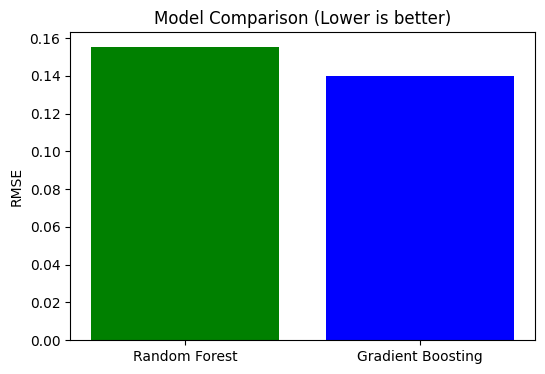

In [49]:

models = ["Random Forest", "Gradient Boosting"]
rmse_scores = [rf_rmse, gbr_rmse]

plt.figure(figsize=(6,4))
plt.bar(models, rmse_scores, color=["green", "blue"])
plt.ylabel("RMSE")
plt.title("Model Comparison (Lower is better)")
plt.show()

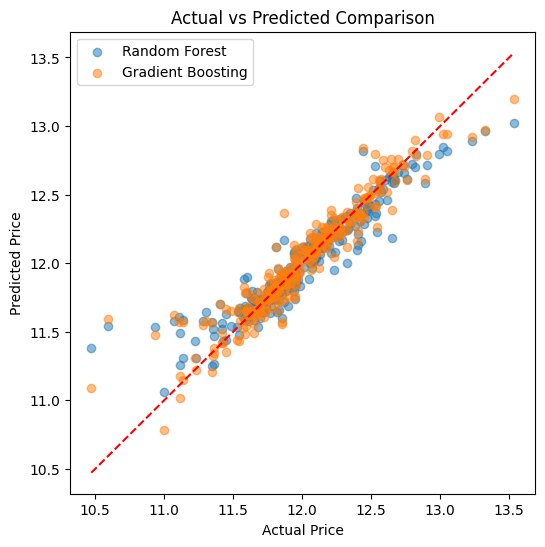

In [50]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred, alpha=0.5, label="Random Forest")
plt.scatter(y_test, gbr_pred, alpha=0.5, label="Gradient Boosting")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.show()

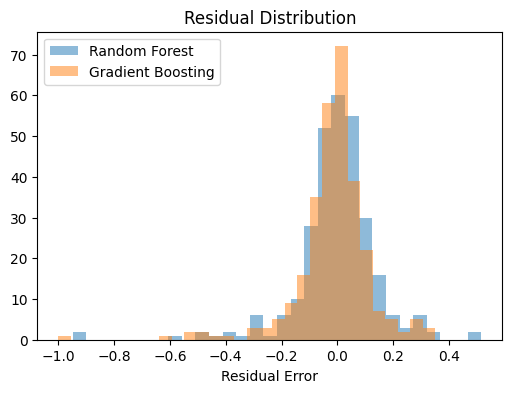

In [51]:
rf_res = y_test - rf_pred
gbr_res = y_test - gbr_pred

plt.figure(figsize=(6,4))

plt.hist(rf_res, bins=30, alpha=0.5, label="Random Forest")
plt.hist(gbr_res, bins=30, alpha=0.5, label="Gradient Boosting")

plt.xlabel("Residual Error")
plt.title("Residual Distribution") # tighter is good
plt.legend()
plt.show()